  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  year  month  \
0           1            0                    5         224  2022      1   
1           1            1                    1         348  2022      1   
2           1            0                    6         249  2022      1   
3           1            0                    7         259  2022      1   
4           0            0                    3         277  2022      1   

   day_of_week  is_month_end  
0            5             0  
1            5             0  
2          

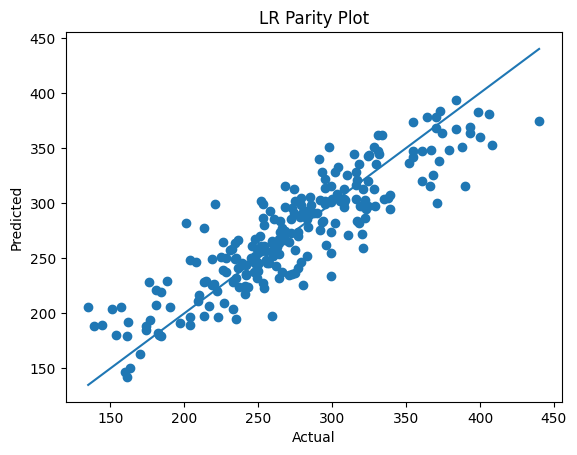

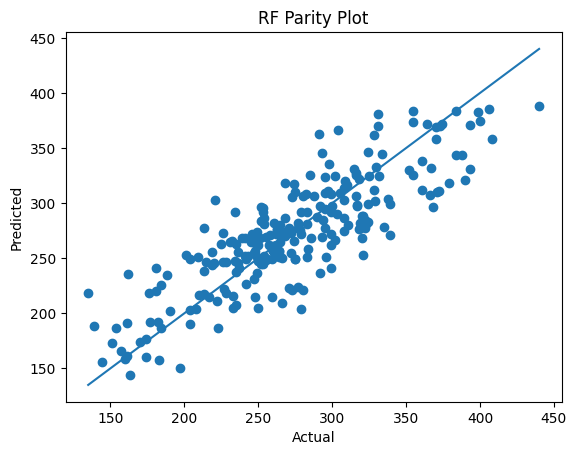

                     feature  importance
7      cat__store_size_small    0.183954
10          num__is_festival    0.174477
5   cat__location_type_urban    0.140498
14          num__day_of_week    0.090612
9            num__is_weekend    0.063547


In [15]:
##======Q3 = FEATURE ENGINEERING AND REGRESION PIPLINE

import pandas as pd

## TASK-1 DATE FEATURE ENGINEERING

data = pd.read_csv("q3_retail_promotions.csv")

data['transaction_date'] = pd.to_datetime(data['transaction_date'])

data['year'] = data['transaction_date'].dt.year
data['month'] = data['transaction_date'].dt.month
data['day_of_week'] = data['transaction_date'].dt.dayofweek

data['is_month_end'] = (data['transaction_date'].dt.day >= 25).astype(int)

print(data.head())

## TASK-2 TEMPORAL TRAIN-TEAT SPLIT

data = data.sort_values(by='transaction_date').reset_index(drop=True)

split_val = int(len(data) * 0.8)

train_data = data.iloc[:split_val]
test_data = data.iloc[split_val:]

## TASK-3 PREPROCESSING PIPELINE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [
    'store_id', 'is_weekend', 'is_festival',
    'competition_density', 'year', 'month',
    'day_of_week', 'is_month_end'
]

col_trans = ColumnTransformer(
    transformers=[
        ('cat_part', OneHotEncoder(drop='first'), cat_cols),
        ('num_part', StandardScaler(), num_cols)
    ]
)

## TASK-4 MODEL TRAINING AND EVALUTION

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

X_tr = train_data.drop(['items_sold', 'transaction_date'], axis=1)
y_tr = train_data['items_sold']

X_te = test_data.drop(['items_sold', 'transaction_date'], axis=1)
y_te = test_data['items_sold']

## LINEAR REGRESION
cat_features = ['promotion_type', 'location_type', 'store_size']
num_features = [
    'store_id', 'is_weekend', 'is_festival',
    'competition_density', 'year', 'month',
    'day_of_week', 'is_month_end'
]

column_proc = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)
lr_pipe = Pipeline([
    ('prep', column_proc),
    ('model', LinearRegression())
])

lr_pipe.fit(X_tr, y_tr)

pred_lr = lr_pipe.predict(X_te)

rmse_lr = np.sqrt(mean_squared_error(y_te, pred_lr))
mae_lr = mean_absolute_error(y_te, pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)


## RANDOM FOREST

rf_pipe = Pipeline([
    ('prep_step', column_proc),
    ('rf_model', RandomForestRegressor(random_state=42))
])

rf_pipe.fit(X_tr, y_tr)

pred_rf = rf_pipe.predict(X_te)

rmse_rf_val = np.sqrt(mean_squared_error(y_te, pred_rf))
mae_rf_val = mean_absolute_error(y_te, pred_rf)

print("RF RMSE:", rmse_rf_val)
print("RF MAE:", mae_rf_val)

## PARITY PLOT (linear)

import matplotlib.pyplot as plt

plt.scatter(y_te, pred_lr)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LR Parity Plot")
plt.show()

## PARITY PLOT (random forest)
plt.scatter(y_te, pred_rf)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()])
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("RF Parity Plot")
plt.show()

## IMPORTANCE FEATURE TOP5

rf_m = rf_pipe.named_steps['rf_model']
feat_names = rf_pipe.named_steps['prep_step'].get_feature_names_out()

imp_vals = rf_m.feature_importances_

imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance': imp_vals
}).sort_values(by='importance', ascending=False)

print(imp_df.head(5))